In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/Clean_data.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  7000 non-null   int64  
 1   gender                               7000 non-null   str    
 2   occupation                           7000 non-null   str    
 3   region                               7000 non-null   str    
 4   most_used_platform                   7000 non-null   str    
 5   platforms_used_count                 7000 non-null   int64  
 6   daily_screen_hours                   7000 non-null   float64
 7   daily_notifications                  7000 non-null   int64  
 8   night_time_use                       7000 non-null   str    
 9   minutes_to_first_check_after_waking  7000 non-null   int64  
 10  primary_purpose                      7000 non-null   str    
 11  avg_sleep_hours                      7000

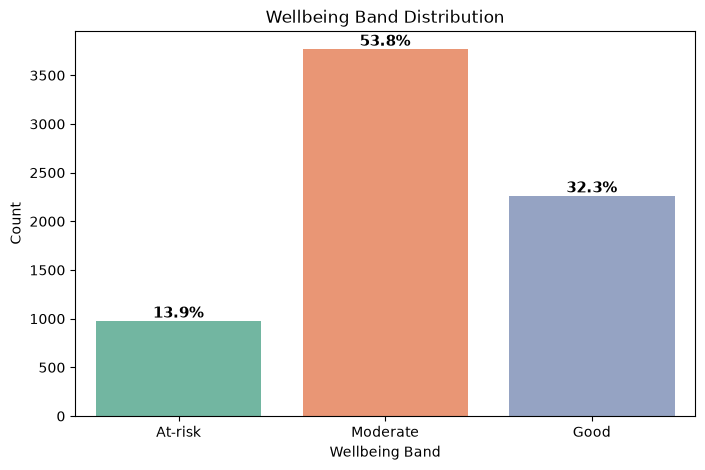

In [4]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="wellbeing_band",
    hue="wellbeing_band",      # Different color for each bar
    palette="Set2",
    legend=False
)

plt.title("Wellbeing Band Distribution")
plt.xlabel("Wellbeing Band")
plt.ylabel("Count")

# Add percentage labels
total = len(df)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

plt.savefig(
    "../reports/figures/Wellbeing_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

    
plt.show()


## ScreenHour Vs BAnd

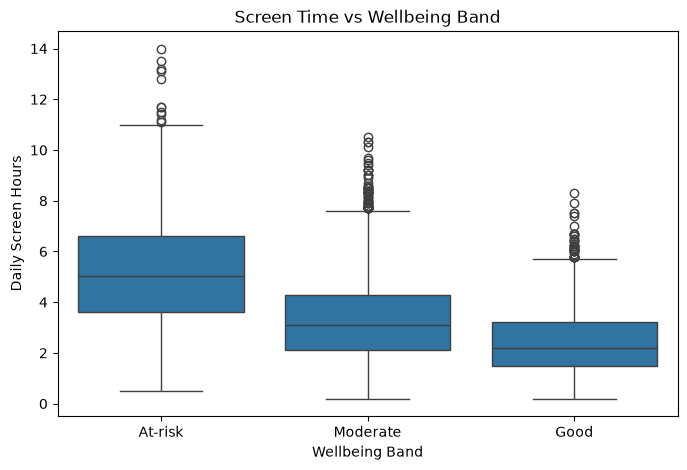

'Insight: Individuals in the At-risk wellbeing category exhibit the highest median daily screen time (~5 hours),\nwhile those in the Good wellbeing category have the lowest median (~2 hours).\nThis suggests an inverse relationship between daily screen time and overall wellbeing.\nAdditionally, the At-risk group shows greater variability and more extreme high-screen-time outliers, \nindicating that excessive screen use may be associated with poorer wellbeing.'

In [5]:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="daily_screen_hours",
    
)

plt.title("Screen Time vs Wellbeing Band")
plt.xlabel("Wellbeing Band")
plt.ylabel("Daily Screen Hours")
plt.show()

'''Insight: Individuals in the At-risk wellbeing category exhibit the highest median daily screen time (~5 hours),
while those in the Good wellbeing category have the lowest median (~2 hours).
This suggests an inverse relationship between daily screen time and overall wellbeing.
Additionally, the At-risk group shows greater variability and more extreme high-screen-time outliers, 
indicating that excessive screen use may be associated with poorer wellbeing.'''

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\3682195168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


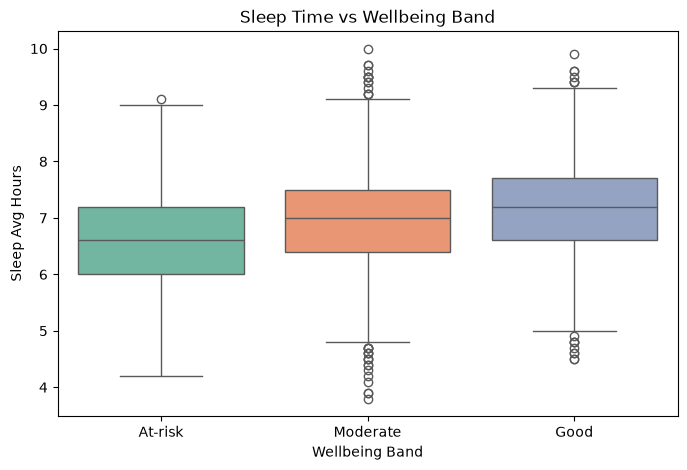

In [6]:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="avg_sleep_hours",
    palette="Set2"
)

plt.title("Sleep Time vs Wellbeing Band")
plt.xlabel("Wellbeing Band")
plt.ylabel("Sleep Avg Hours")
plt.savefig(
    "../reports/figures/Aveg_Sleep vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\74616168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


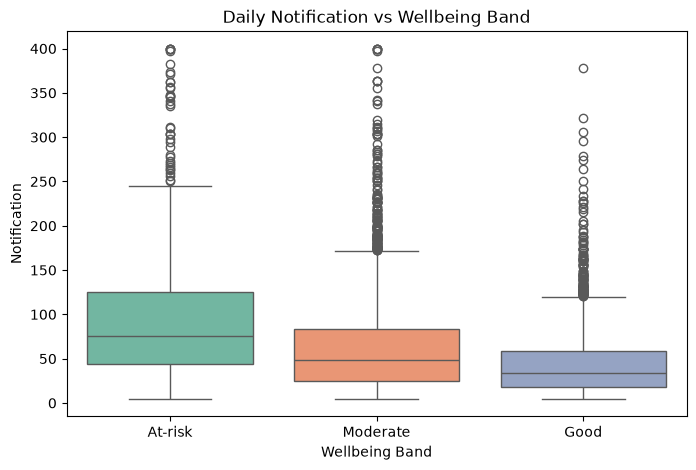

In [7]:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="daily_notifications",
    palette="Set2"
)

plt.title("Daily Notification vs Wellbeing Band")
plt.xlabel("Wellbeing Band")
plt.ylabel("Notification")
plt.show()

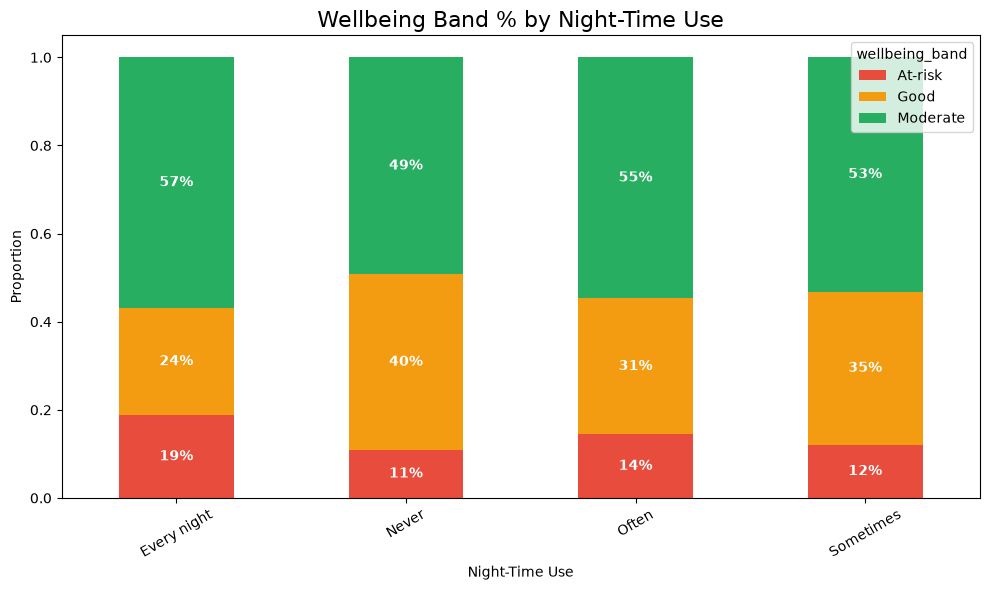

'Observation: Individuals who use social media every night show the highest proportion of At-risk wellbeing and the lowest proportion of Good wellbeing.\n In contrast, those who never use social media at night have the largest share of Good wellbeing and the smallest share of At-risk individuals.\n This indicates that frequent night-time social media use may be associated with poorer mental wellbeing.\n'

In [8]:

cross_tab = pd.crosstab(
    df["night_time_use"],
    df["wellbeing_band"],
    normalize="index"
)

ax = cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=["#e74c3c", "#f39c12", "#27ae60"]
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{v.get_height()*100:.0f}%" if v.get_height() > 0.05 else ""
        for v in container
    ]
    ax.bar_label(container, labels=labels, label_type="center",
                 color="white", fontsize=10, fontweight="bold")

plt.title("Wellbeing Band % by Night-Time Use", fontsize=16)
plt.xlabel("Night-Time Use")
plt.ylabel("Proportion")
plt.xticks(rotation=30)
plt.legend(title="wellbeing_band")
plt.tight_layout()
plt.savefig(
    "../reports/figures/Night_Time_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
"""Observation: Individuals who use social media every night show the highest proportion of At-risk wellbeing and the lowest proportion of Good wellbeing.
 In contrast, those who never use social media at night have the largest share of Good wellbeing and the smallest share of At-risk individuals.
 This indicates that frequent night-time social media use may be associated with poorer mental wellbeing.
"""

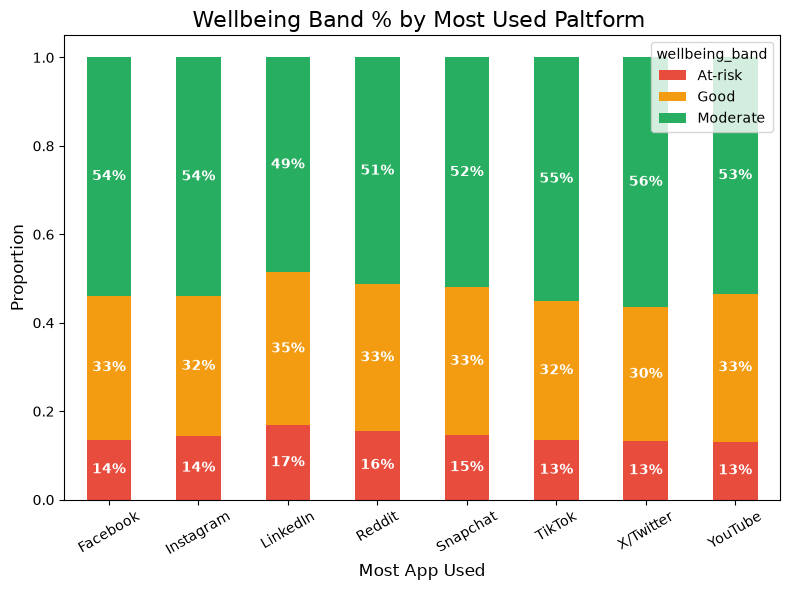

In [9]:
# Create a cross-tabulation with percentages
cross_tab = pd.crosstab(
    df["most_used_platform"],
    df["wellbeing_band"],
    normalize="index"
)

# Plot
ax = cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=["#e74c3c", "#f39c12", "#27ae60"]  # Red, Orange, Green
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{v.get_height()*100:.0f}%" if v.get_height() > 0.05 else ""
        for v in container
    ]
    ax.bar_label(container, labels=labels, label_type="center",
                 color="white", fontsize=10, fontweight="bold")
plt.title("Wellbeing Band % by Most Used Paltform ", fontsize=16)
plt.xlabel("Most App Used", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="wellbeing_band")
plt.tight_layout()
plt.savefig(
    "../reports/figures/Most_used_platform_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


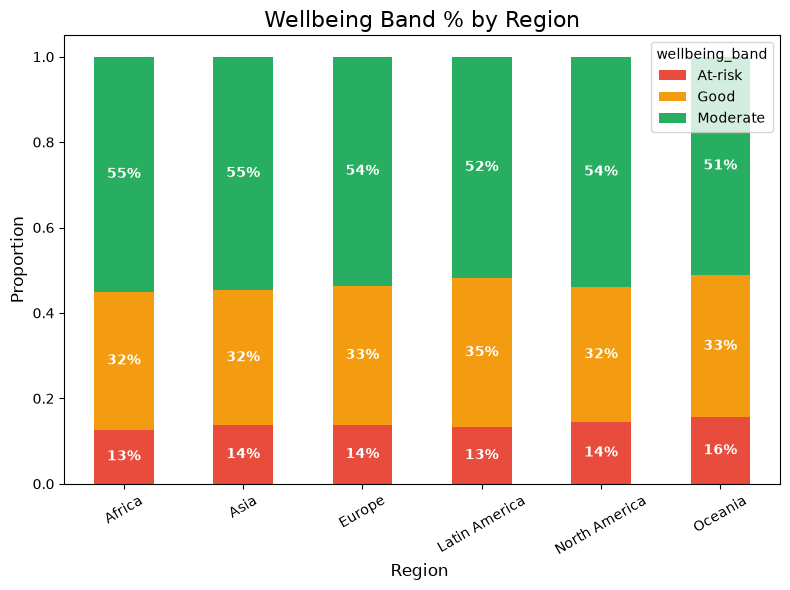

In [10]:
# Create a cross-tabulation with percentages
cross_tab = pd.crosstab(
    df["region"],
    df["wellbeing_band"],
    normalize="index"
)

# Plot
ax = cross_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=["#e74c3c", "#f39c12", "#27ae60"]  # Red, Orange, Green
)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{v.get_height()*100:.0f}%" if v.get_height() > 0.05 else ""
        for v in container
    ]
    ax.bar_label(container, labels=labels, label_type="center",
                 color="white", fontsize=10, fontweight="bold")
plt.title("Wellbeing Band % by Region", fontsize=16)
plt.xlabel("Region ", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="wellbeing_band")
plt.tight_layout()
plt.savefig(
    "../reports/figures/region_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


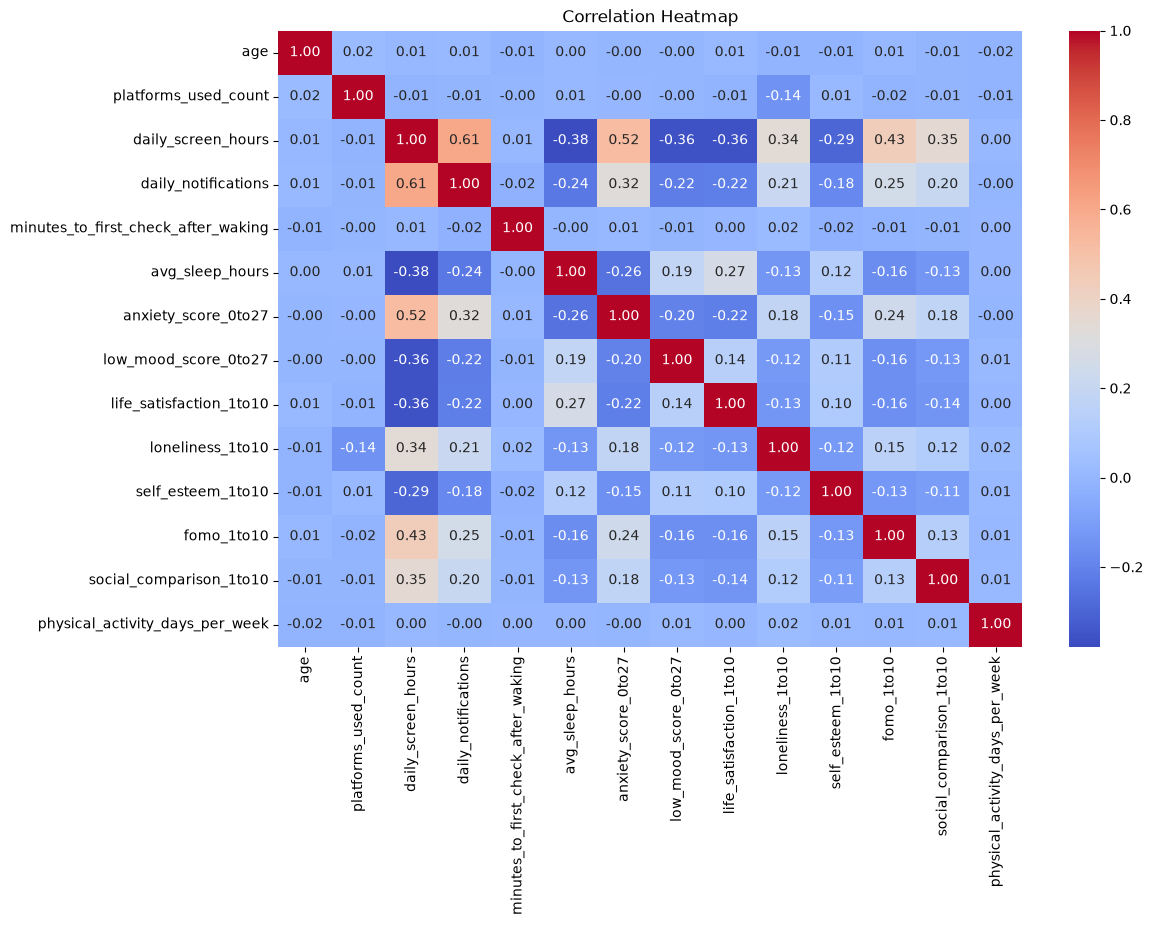

In [11]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.savefig(
    "../reports/figures/Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.title("Correlation Heatmap")
plt.show()

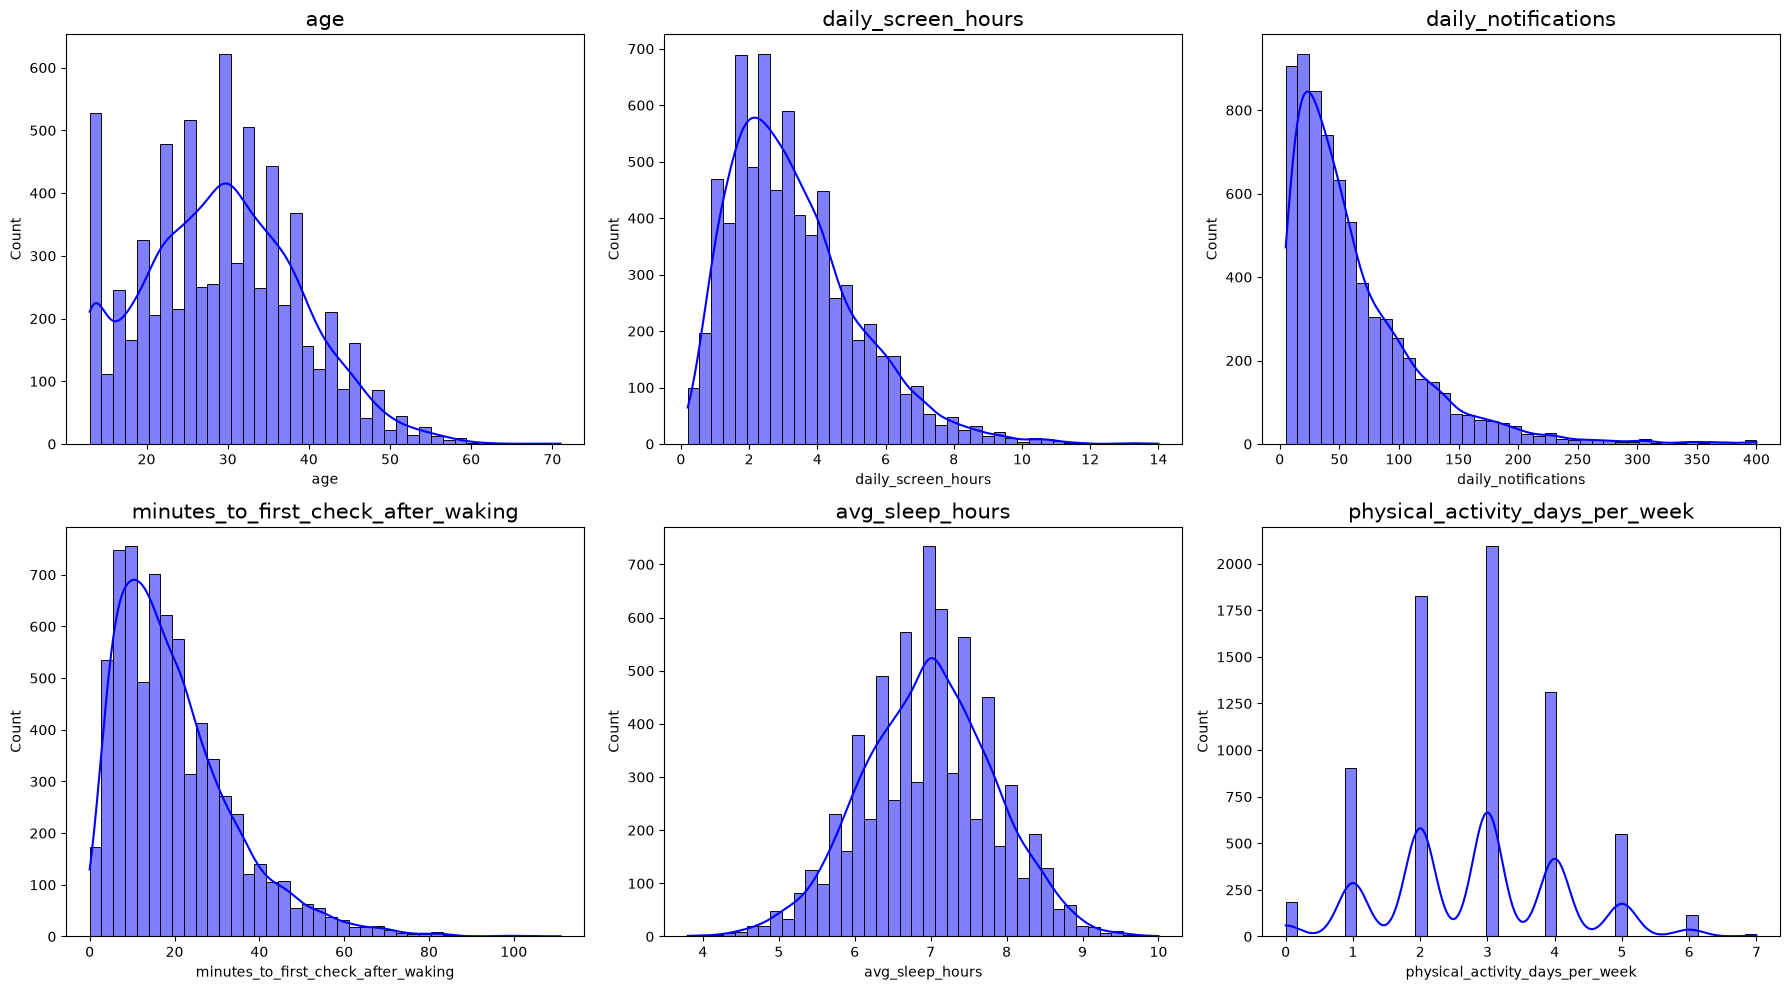

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
num_cols = [
    "age",
    "daily_screen_hours",
    "daily_notifications",
    "minutes_to_first_check_after_waking",
    "avg_sleep_hours",
    "physical_activity_days_per_week"
]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each numerical column
for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=40,
        ax=axes[i],
        color="blue"
    )
    axes[i].set_title(col, fontsize=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.savefig(
    "../reports/figures/numeric_col_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\1175032934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


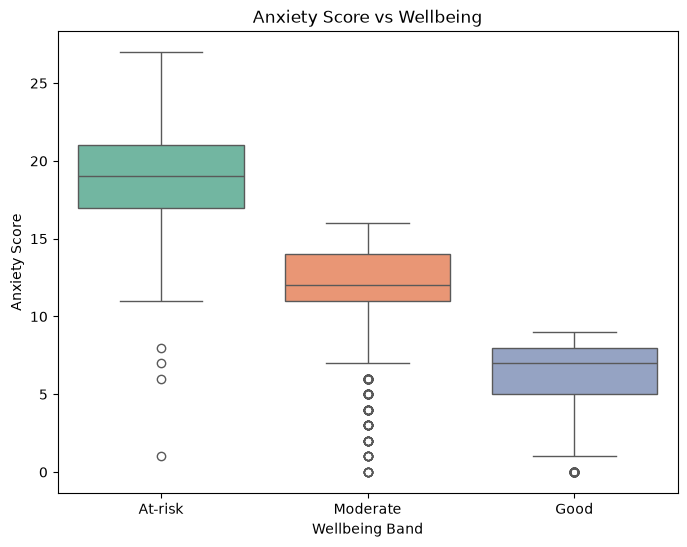

In [13]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="anxiety_score_0to27",
    palette="Set2"
)

plt.title("Anxiety Score vs Wellbeing")
plt.xlabel("Wellbeing Band")
plt.ylabel("Anxiety Score")

plt.savefig(
    f"../reports/figures/anxiety_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\967876190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


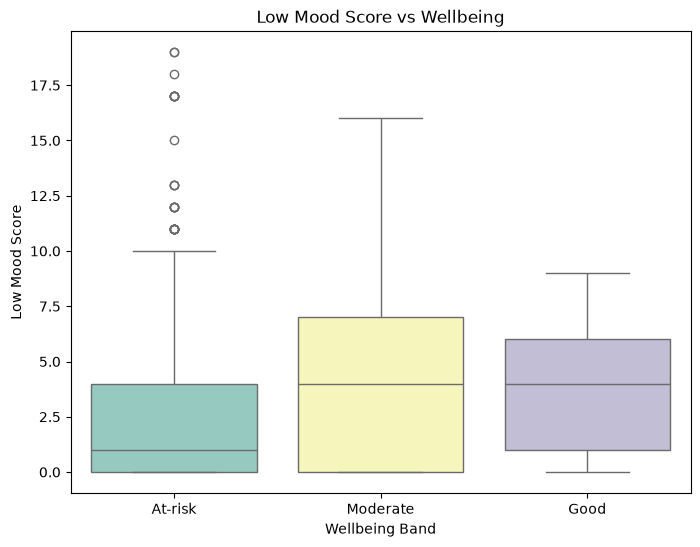

In [14]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="low_mood_score_0to27",
    palette="Set3"
)

plt.title("Low Mood Score vs Wellbeing")
plt.xlabel("Wellbeing Band")
plt.ylabel("Low Mood Score")

plt.savefig(
    f"../reports/figures/low_mood_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\4017632494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


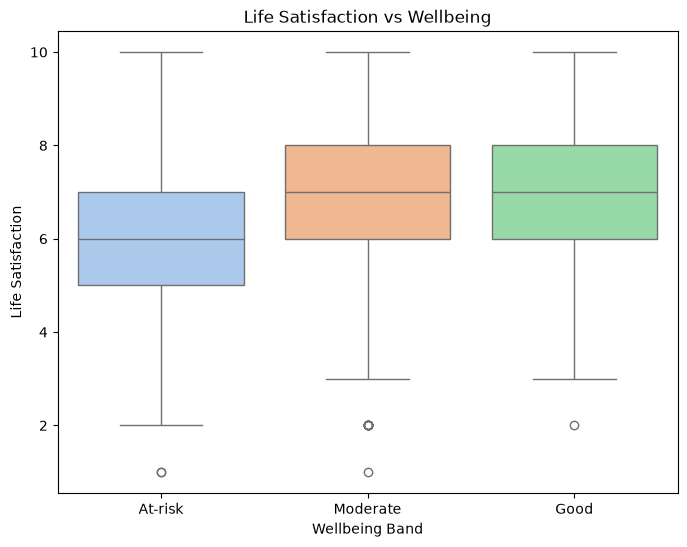

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="life_satisfaction_1to10",
    palette="pastel"
)

plt.title("Life Satisfaction vs Wellbeing")
plt.xlabel("Wellbeing Band")
plt.ylabel("Life Satisfaction")

plt.savefig(
    f"../reports/figures/life_satisfaction_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\2369992710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


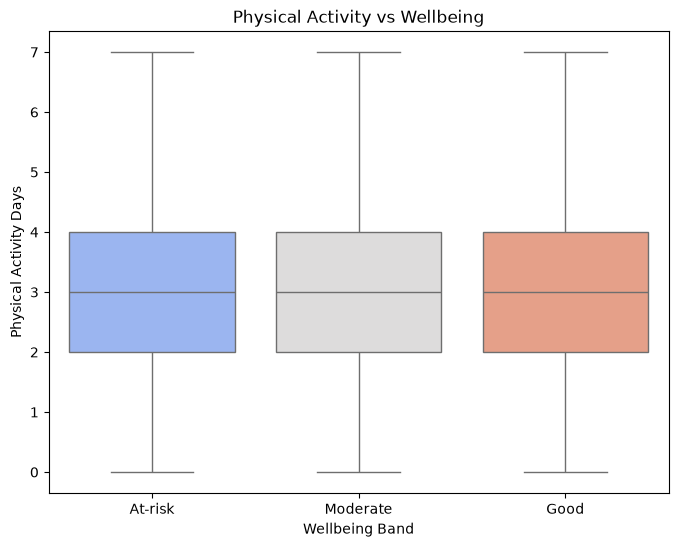

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="physical_activity_days_per_week",
    palette="coolwarm"
)

plt.title("Physical Activity vs Wellbeing")
plt.xlabel("Wellbeing Band")
plt.ylabel("Physical Activity Days")

plt.savefig(
    f"../reports/figures//physical_activity_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\1960121651.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


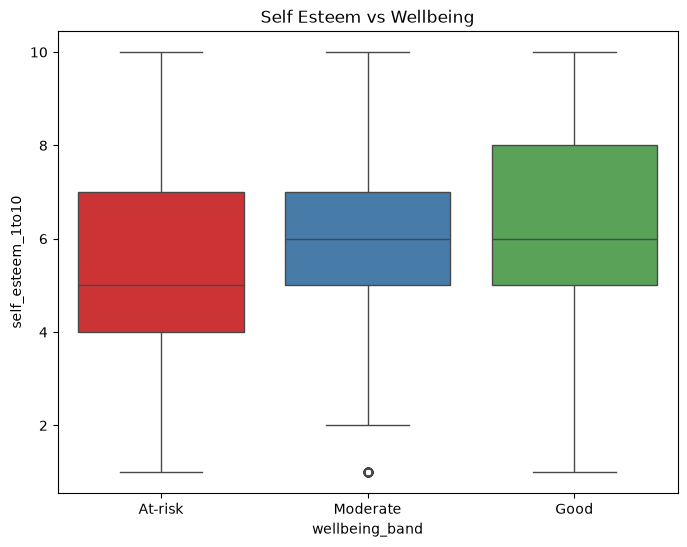

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="self_esteem_1to10",
    palette="Set1"
)

plt.title("Self Esteem vs Wellbeing")

plt.savefig(
    f"../reports/figures//self_esteem_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\2340467637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


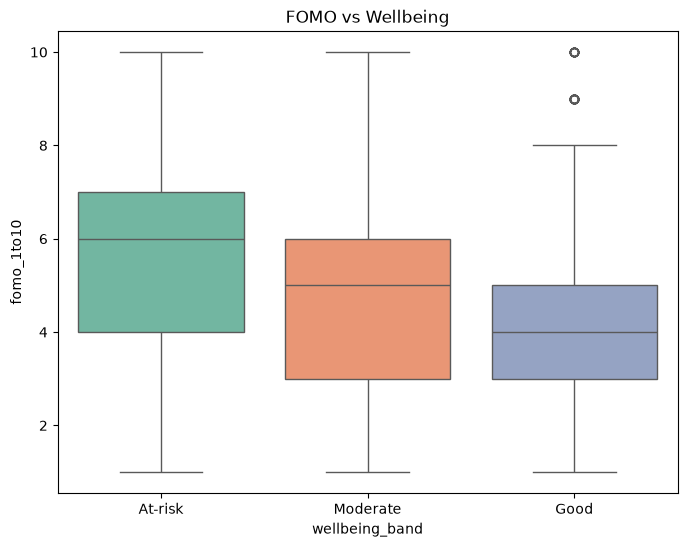

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="fomo_1to10",
    palette="Set2"
)

plt.title("FOMO vs Wellbeing")

plt.savefig(
    f"../reports/figures//fomo_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\3914797042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


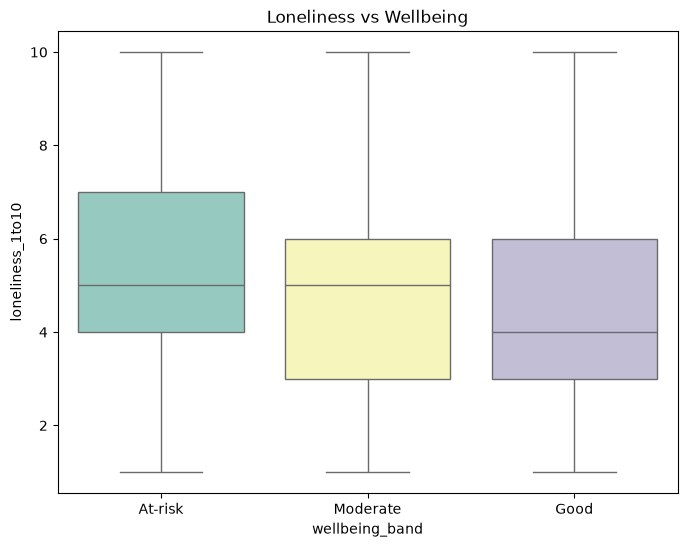

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="loneliness_1to10",
    palette="Set3"
)

plt.title("Loneliness vs Wellbeing")

plt.savefig(
    f"../reports/figures//loneliness_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\4152178653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


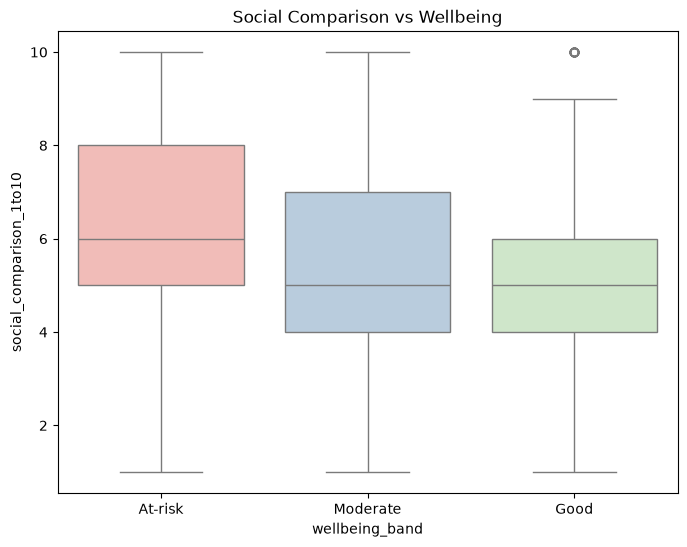

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="wellbeing_band",
    y="social_comparison_1to10",
    palette="Pastel1"
)

plt.title("Social Comparison vs Wellbeing")

plt.savefig(
    f"../reports/figures//social_comparison_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

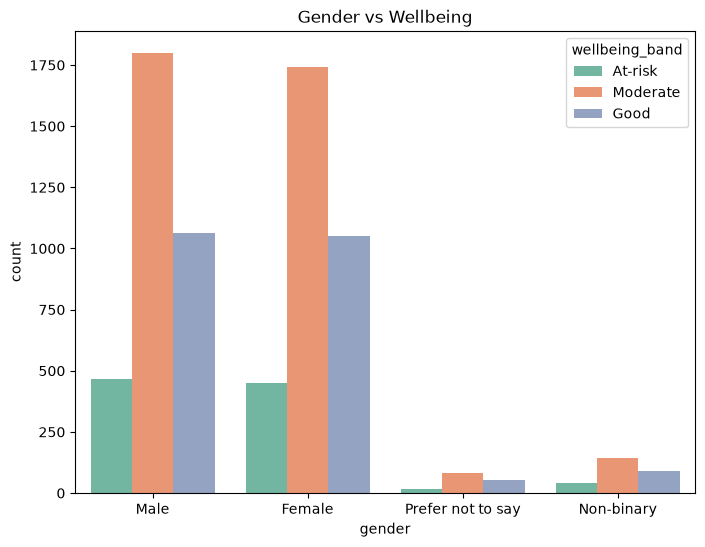

In [21]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="gender",
    hue="wellbeing_band",
    palette="Set2"
)

plt.title("Gender vs Wellbeing")

plt.savefig(
    f"../reports/figures//gender_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

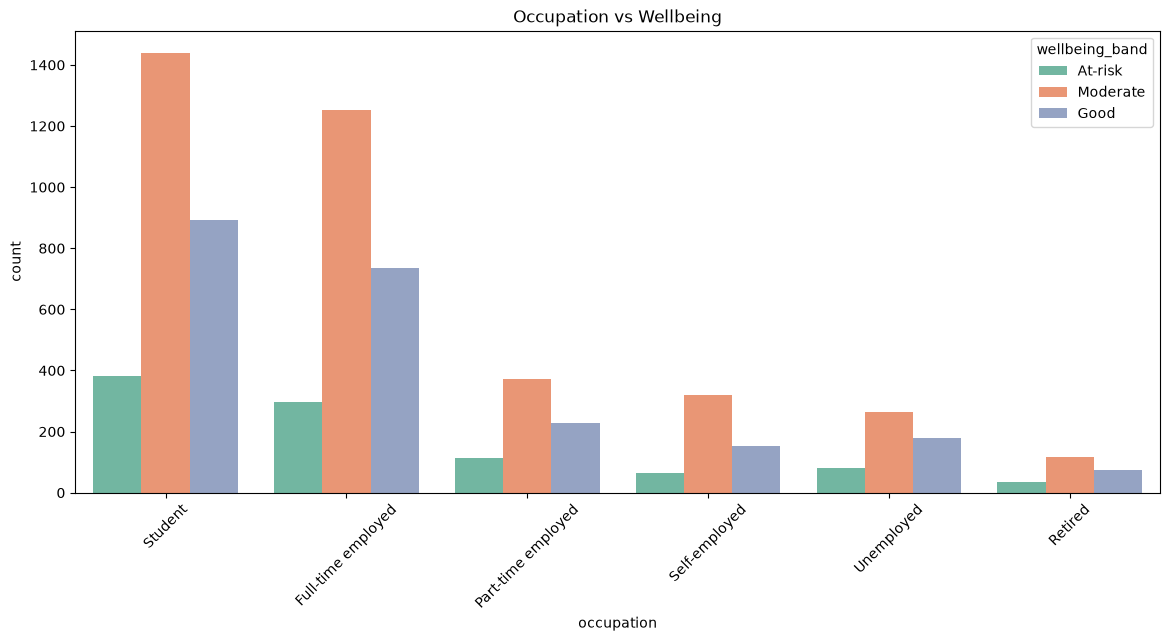

In [22]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="occupation",
    hue="wellbeing_band",
    palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Occupation vs Wellbeing")

plt.savefig(
    f"../reports/figures//occupation_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

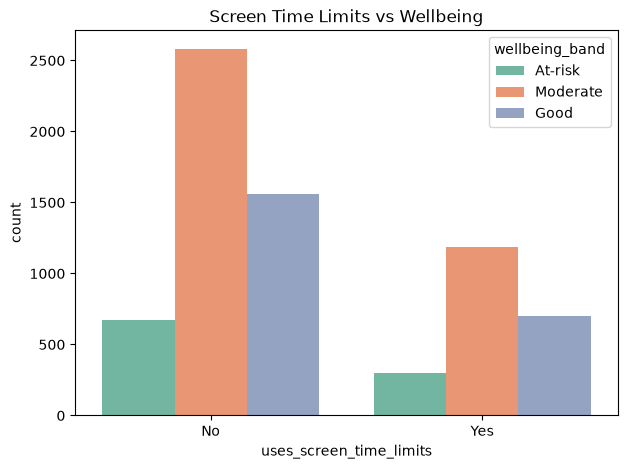

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="uses_screen_time_limits",
    hue="wellbeing_band",
    palette="Set2"
)

plt.title("Screen Time Limits vs Wellbeing")

plt.savefig(
    f"../reports/figures/screen_time_limits_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

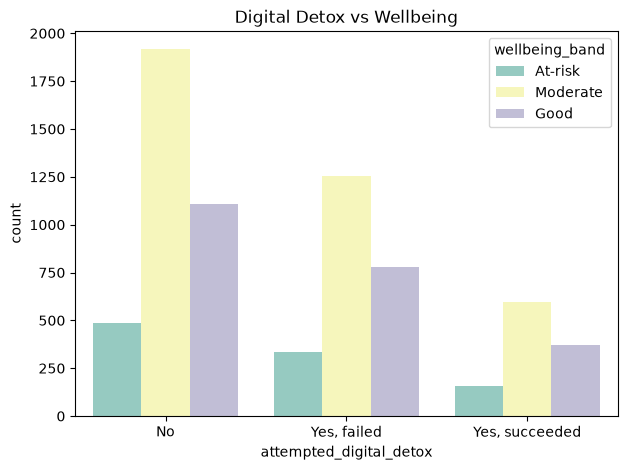

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="attempted_digital_detox",
    hue="wellbeing_band",
    palette="Set3"
)

plt.title("Digital Detox vs Wellbeing")

plt.savefig(
    f"../reports/figures/digital_detox_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

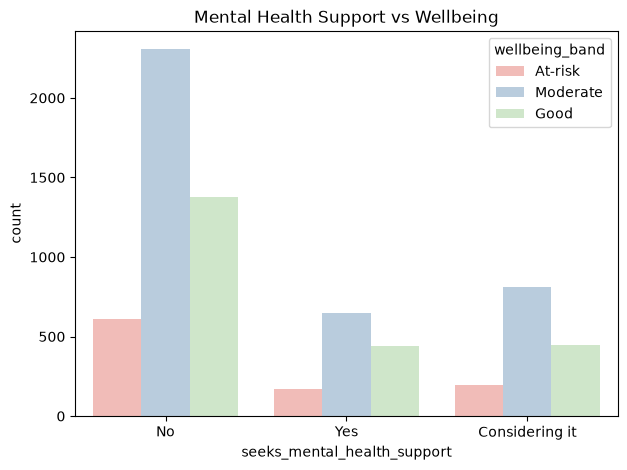

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="seeks_mental_health_support",
    hue="wellbeing_band",
    palette="Pastel1"
)

plt.title("Mental Health Support vs Wellbeing")

plt.savefig(
    f"../reports/figures//mental_health_support_vs_wellbeing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

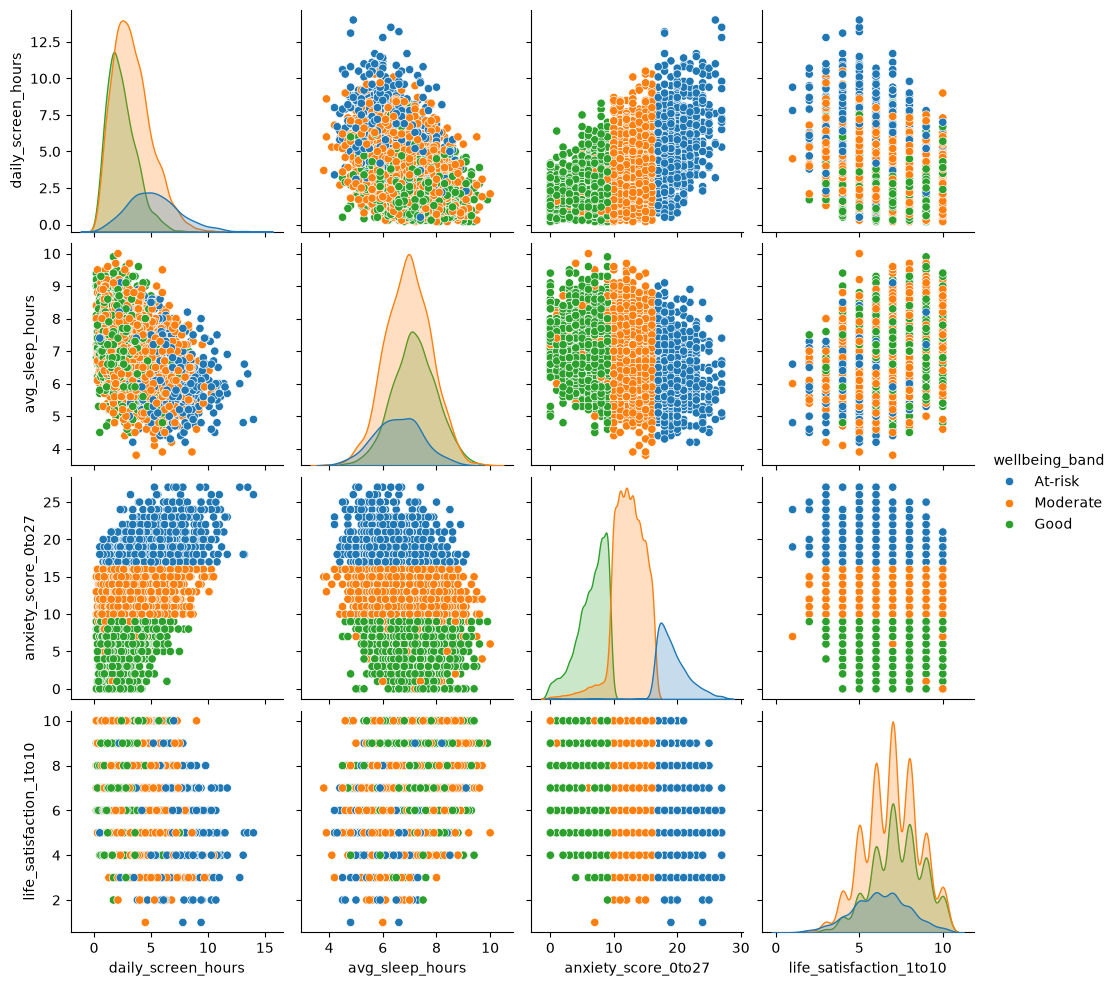

In [26]:
pair = sns.pairplot(
    df[
        [
            "daily_screen_hours",
            "avg_sleep_hours",
            "anxiety_score_0to27",
            "life_satisfaction_1to10",
            "wellbeing_band"
        ]
    ],
    hue="wellbeing_band"
)

pair.savefig(
    f"../reports/figures//pairplot.png",
    dpi=300
)

plt.show()

C:\Users\omjee\AppData\Local\Temp\ipykernel_21748\788129798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


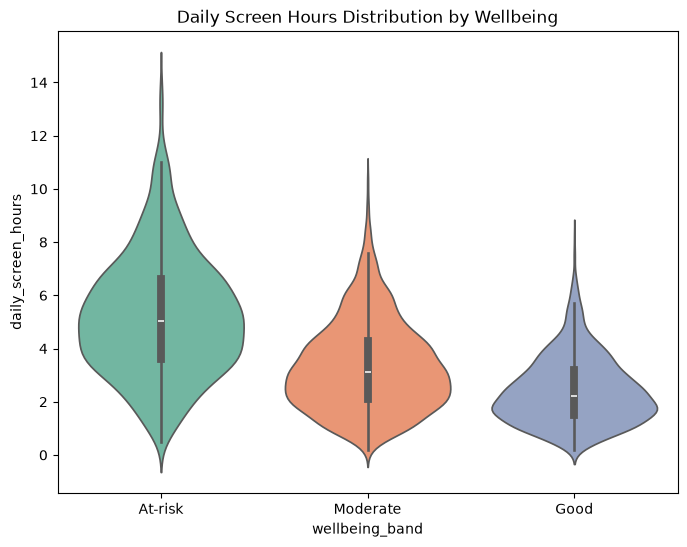

In [27]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="wellbeing_band",
    y="daily_screen_hours",
    palette="Set2"
)

plt.title("Daily Screen Hours Distribution by Wellbeing")

plt.savefig(
    f"../reports/figures//violin_screen_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
df.columns

Index(['age', 'gender', 'occupation', 'region', 'most_used_platform',
       'platforms_used_count', 'daily_screen_hours', 'daily_notifications',
       'night_time_use', 'minutes_to_first_check_after_waking',
       'primary_purpose', 'avg_sleep_hours', 'anxiety_score_0to27',
       'low_mood_score_0to27', 'life_satisfaction_1to10', 'loneliness_1to10',
       'self_esteem_1to10', 'fomo_1to10', 'social_comparison_1to10',
       'physical_activity_days_per_week', 'uses_screen_time_limits',
       'attempted_digital_detox', 'seeks_mental_health_support',
       'wellbeing_band'],
      dtype='str')

In [38]:
df['seeks_mental_health_support'].unique()

<ArrowStringArray>
['No', 'Yes', 'Considering it']
Length: 3, dtype: str

In [32]:
df.describe()

,age,platforms_used_count,daily_screen_hours,daily_notifications,minutes_to_first_check_after_waking,avg_sleep_hours,anxiety_score_0to27,low_mood_score_0to27,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,29.246571,3.494571,3.304971,61.528286,20.008286,6.965514,11.378000,3.845714,6.955857,4.679286,6.006857,4.641857,5.323286,2.804143
std,9.569132,1.763637,1.881350,54.879070,13.976229,0.864031,4.777726,3.534197,1.614486,2.094803,1.886767,2.157439,2.090788,1.288418
min,13.000000,1.000000,0.200000,5.000000,0.000000,3.800000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,22.000000,2.000000,1.900000,24.000000,10.000000,6.400000,8.000000,0.000000,6.000000,3.000000,5.000000,3.000000,4.000000,2.000000
50%,29.000000,3.000000,3.000000,45.500000,17.000000,7.000000,11.000000,3.000000,7.000000,5.000000,6.000000,5.000000,5.000000,3.000000
75%,36.000000,5.000000,4.300000,83.000000,27.000000,7.500000,14.000000,6.000000,8.000000,6.000000,7.000000,6.000000,7.000000,4.000000
max,71.000000,8.000000,14.000000,400.000000,111.000000,10.000000,27.000000,19.000000,10.000000,10.000000,10.000000,10.000000,10.000000,7.000000
